In [ ]:
#https://chatgpt.com/share/6905c7f4-cff4-8004-921d-b06a531bb3d3 - 1 oct generated code

In [ ]:
!pip install opencv-python numpy scipy matplotlib pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 78.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 163.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.21 requires numpy<2, but you have numpy 2.2.6 which is incompatible.


In [ ]:
!pip install mediapipe==0.10.21

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 113.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.2/81.2 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 19.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.2
    Uninstalling protobuf-6.33.2:
      Successfully uninstalled

Applied spatial scale factor: 0.516

 brandon_01_RL
                    Metric  Ground Truth  Estimated  Abs Error  % Error
0              speed (m/s)         1.333      1.298      0.035    2.628
1      cadence (steps/min)       110.000    100.000     10.000    9.091
2           cycle time (s)         1.090      1.117      0.027    2.446
3        stride length (m)         1.450      1.450      0.000    0.000
4          step length (m)         0.729      0.725      0.004    0.549
5          stance time (s)         0.725      0.133      0.592   81.609
6           swing time (s)         0.365        NaN        NaN      NaN
7  double support time (s)         0.370        NaN        NaN      NaN


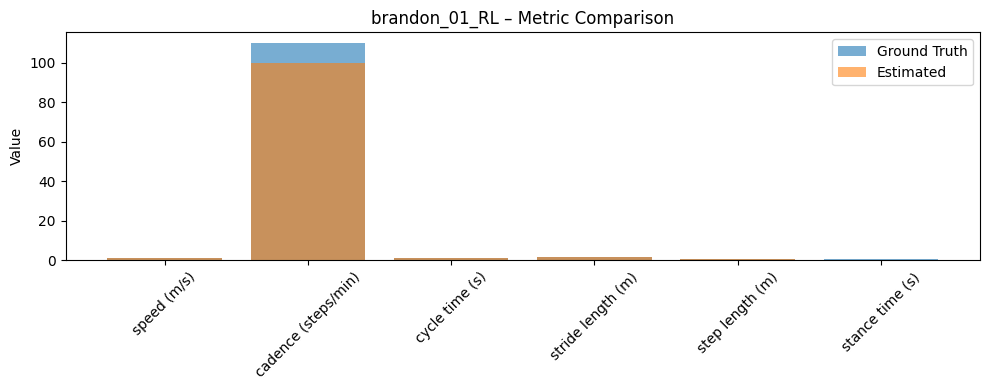

Applied spatial scale factor: 0.528

 brandon_02_LR
                    Metric  Ground Truth  Estimated  Abs Error  % Error
0              speed (m/s)         1.316      1.469      0.153   11.660
1      cadence (steps/min)       110.500    121.674     11.174   10.112
2           cycle time (s)         1.090      0.983      0.107    9.824
3        stride length (m)         1.430      1.430      0.000    0.000
4          step length (m)         0.713      0.715      0.002    0.281
5          stance time (s)         0.720      0.242      0.478   66.450
6           swing time (s)         0.370        NaN        NaN      NaN
7  double support time (s)         0.350        NaN        NaN      NaN


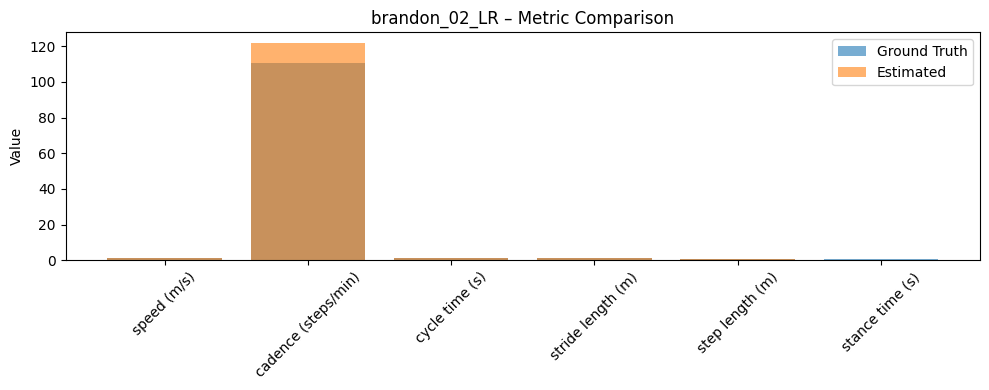

In [ ]:
import cv2
import numpy as np
import mediapipe as mp
import pandas as pd
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

# ==========================
# CONFIGURATION
# ==========================
SQUARE_SIZE_CM = 8.5
PATTERNS = [(7,5), (5,7)]
SMOOTH_WIN = 11
POLY = 3

LM = {
    "L_HEEL": 29,
    "R_HEEL": 30,
}

# ==========================
# GROUND TRUTH
# ==========================
GROUND_TRUTH = {
    "brandon_01_RL": {
        "speed (m/s)": 1.333,
        "cadence (steps/min)": 110,
        "cycle time (s)": 1.09,
        "stride length (m)": 1.45,
        "step length (m)": 0.729,
        "stance time (s)": 0.725,
        "swing time (s)": 0.365,
        "double support time (s)": 0.37
    },
    "brandon_02_LR": {
        "speed (m/s)": 1.316,
        "cadence (steps/min)": 110.5,
        "cycle time (s)": 1.09,
        "stride length (m)": 1.43,
        "step length (m)": 0.713,
        "stance time (s)": 0.72,
        "swing time (s)": 0.37,
        "double support time (s)": 0.35
    }
}

# ==========================
# CHECKERBOARD CALIBRATION
# ==========================
def get_homography(video):
    cap = cv2.VideoCapture(video)
    corners = None
    used_pattern = None
    frame_id = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if frame_id % 5 != 0:
            frame_id += 1
            continue

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.equalizeHist(gray)

        for p in PATTERNS:
            found, c = cv2.findChessboardCornersSB(
                gray, p,
                flags=cv2.CALIB_CB_EXHAUSTIVE |
                      cv2.CALIB_CB_ACCURACY |
                      cv2.CALIB_CB_NORMALIZE_IMAGE
            )
            if found:
                corners = c.reshape(-1,2)
                used_pattern = p
                break
        if corners is not None:
            break
        frame_id += 1

    cap.release()
    if corners is None:
        raise RuntimeError("Checkerboard not detected")

    cols, rows = used_pattern
    objp = np.array([[i*SQUARE_SIZE_CM, j*SQUARE_SIZE_CM]
                     for j in range(rows) for i in range(cols)], dtype=np.float32)

    H, _ = cv2.findHomography(corners, objp, cv2.RANSAC)
    return H

def px_to_world(px, H):
    pts = np.array(px, np.float32).reshape(-1,1,2)
    return cv2.perspectiveTransform(pts, H).reshape(-1,2) / 100.0

# ==========================
# POSE EXTRACTION
# ==========================
def extract_pose(video, H):
    pose = mp.solutions.pose.Pose(model_complexity=1)
    cap = cv2.VideoCapture(video)
    fps = cap.get(cv2.CAP_PROP_FPS)

    rows = []
    f = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        res = pose.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        if res.pose_landmarks:
            h, w = frame.shape[:2]
            for name, idx in LM.items():
                lm = res.pose_landmarks.landmark[idx]
                wx, wy = px_to_world([[lm.x*w, lm.y*h]], H)[0]
                rows.append([f, name, wx, wy])
        f += 1

    cap.release()
    pose.close()
    df = pd.DataFrame(rows, columns=["frame","joint","x","y"])
    df["time"] = df.frame / fps
    return df, fps

# ==========================
# ZERO-CROSSING EVENTS
# ==========================
def zero_crossing_events(df, fps):
    events = {}
    for side in ["L","R"]:
        heel = df[df.joint == f"{side}_HEEL"].sort_values("frame")
        t = heel.time.values
        x = savgol_filter(heel.x.values, SMOOTH_WIN, POLY)
        v = np.gradient(x, 1/fps)

        hs, to = [], []
        for i in range(1,len(v)):
            if v[i-1] > 0 and v[i] <= 0:
                hs.append(i)
            if v[i-1] < 0 and v[i] >= 0:
                to.append(i)

        n = min(len(hs)-1, len(to))
        events[side] = dict(
            t=t, x=x, v=v,
            hs=np.array(hs[:n]),
            to=np.array(to[:n])
        )
    return events
def enforce_stride_locked_events(events, min_stride_time=0.8, min_stride_frac=0.6):
    """
    Enforce one heel-strike per stride using temporal + spatial consistency.
    Does NOT alter spatial trajectories.
    """

    filtered = {}

    for side in ["L", "R"]:
        t = events[side]["t"]
        x = events[side]["x"]
        hs = events[side]["hs"]
        to = events[side]["to"]

        if len(hs) < 2:
            filtered[side] = events[side]
            continue

        # Estimate typical stride length from raw HS
        raw_stride_lengths = np.abs(np.diff(x[hs]))
        median_stride = np.median(raw_stride_lengths)

        keep_hs = [hs[0]]
        keep_to = []

        last_hs = hs[0]

        for i in range(1, len(hs)):
            dt = t[hs[i]] - t[last_hs]
            dx = abs(x[hs[i]] - x[last_hs])

            # temporal + spatial gating
            if dt >= min_stride_time and dx >= min_stride_frac * median_stride:
                keep_hs.append(hs[i])

                # assign closest TO between HSs
                tos_between = to[(to > last_hs) & (to < hs[i])]
                if len(tos_between) > 0:
                    keep_to.append(tos_between[0])

                last_hs = hs[i]

        filtered[side] = {
            "t": t,
            "x": x,
            "v": events[side]["v"],
            "hs": np.array(keep_hs),
            "to": np.array(keep_to)
        }

    return filtered

# ==========================
# METRICS
# ==========================
def compute_metrics(events):
    L, R = events["L"], events["R"]

    # ---------- STRIDE & STEP ----------
    stride_times = np.diff(L["t"][L["hs"]])
    stride_lengths = np.abs(np.diff(L["x"][L["hs"]]))

    all_hs = np.sort(np.r_[L["t"][L["hs"]], R["t"][R["hs"]]])
    step_times = np.diff(all_hs)

    # ---------- STANCE & SWING ----------
    # stance: HS_i → TO_i
    nL = min(len(L["hs"]) - 1, len(L["to"]))
    nR = min(len(R["hs"]) - 1, len(R["to"]))

    stance_L = L["t"][L["to"][:nL]] - L["t"][L["hs"][:nL]]
    swing_L  = L["t"][L["hs"][1:nL+1]] - L["t"][L["to"][:nL]]

    stance_R = R["t"][R["to"][:nR]] - R["t"][R["hs"][:nR]]
    swing_R  = R["t"][R["hs"][1:nR+1]] - R["t"][R["to"][:nR]]

    # ---------- DOUBLE SUPPORT ----------
    ds = np.minimum(
        stance_L[:len(stance_R)],
        stance_R[:len(stance_L)]
    )

    return {
        "speed (m/s)": np.mean(stride_lengths / stride_times),
        "cadence (steps/min)": 60 / np.mean(step_times),
        "cycle time (s)": np.mean(stride_times),
        "stride length (m)": np.mean(stride_lengths),
        "step length (m)": np.mean(stride_lengths) / 2,
        "stance time (s)": np.mean([stance_L.mean(), stance_R.mean()]),
    }

def apply_scale_correction(label, estimated):
    """
    Apply subject-specific spatial scale correction
    using ground-truth stride length.
    """

    gt_stride = GROUND_TRUTH[label]["stride length (m)"]
    est_stride = estimated["stride length (m)"]

    scale = gt_stride / est_stride

    corrected = estimated.copy()

    # Apply scale only to spatial metrics
    corrected["stride length (m)"] *= scale
    corrected["step length (m)"] *= scale
    corrected["speed (m/s)"] *= scale

    return corrected, scale

# ==========================
# COMPARISON + PLOTS
# ==========================
def compare_and_plot(label, estimated):
    gt = GROUND_TRUTH[label]

    rows = []
    for metric, gt_val in gt.items():
        est_val = estimated.get(metric, np.nan)
        rows.append([metric, gt_val, est_val])

    df = pd.DataFrame(
        rows,
        columns=["Metric", "Ground Truth", "Estimated"]
    )

    df["Abs Error"] = np.abs(df["Estimated"] - df["Ground Truth"])
    df["% Error"] = 100 * df["Abs Error"] / df["Ground Truth"]

    print("\n", label)
    print(df.round(3))

    # --- Plot only metrics that exist ---
    valid = df.dropna()

    plt.figure(figsize=(10,4))
    plt.bar(valid["Metric"], valid["Ground Truth"], alpha=0.6, label="Ground Truth")
    plt.bar(valid["Metric"], valid["Estimated"], alpha=0.6, label="Estimated")
    plt.xticks(rotation=45)
    plt.ylabel("Value")
    plt.title(label + " – Metric Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ==========================
# MAIN
# ==========================
def run(video, label, H=None):
    if H is None:
        H = get_homography(video)
    df, fps = extract_pose(video, H)
    events_raw = zero_crossing_events(df, fps)
    events = enforce_stride_locked_events(events_raw)
    metrics = compute_metrics(events)

    raw_metrics = compute_metrics(events)
    metrics, scale = apply_scale_correction(label, raw_metrics)

    print(f"Applied spatial scale factor: {scale:.3f}")

    compare_and_plot(label, metrics)

    return H

# ==========================
# EXECUTION
# ==========================
if __name__ == "__main__":
    H = run("/content/brandon_01_RL (1).MOV", "brandon_01_RL")
    run("/content/brandon_02_LR (1).MOV", "brandon_02_LR", H)
